# Bài 1: Biểu diễn dữ liệu thành ma trận và độ tương đồng

## Lựa chọn B - Text

## 1. Biến dữ liệu thành ma trận:

Tạo ma trận X với text là số câu * số từ. In X.shape và giải thích mỗi hàng/cột đại diện cho gì.

Dữ liệu gồm 8 câu thơ được chuyển thành ma trận (Bag-of-Words).
Mỗi hàng là một câu thơ khác nhau.
Mỗi cột là một từ trong từ điển (vocab).

In [129]:
import numpy as np
import matplotlib.pyplot as plt
import re
cau = [
    "Toi yeu em den nay chung co the", 
    "Ngon lua tinh chua han da tan phai", 
    "Nhung khong de em ban long them nua", 
    "Hay hon em phai gon bong u hoai", 
    "Toi yeu em am tham khong hy vong", 
    "Luc rut re khi ham huc long ghen", 
    "Toi yeu em yeu chan thanh dam tham", 
    "Cau em duoc nguoi tinh nhu toi da yeu em"
]

In [130]:
vocab = sorted ({w for s in cau for w in s.lower().split()})

print("So tu trong tu dien", len(vocab))
print(vocab)

So tu trong tu dien 47
['am', 'ban', 'bong', 'cau', 'chan', 'chua', 'chung', 'co', 'da', 'dam', 'de', 'den', 'duoc', 'em', 'ghen', 'gon', 'ham', 'han', 'hay', 'hoai', 'hon', 'huc', 'hy', 'khi', 'khong', 'long', 'lua', 'luc', 'nay', 'ngon', 'nguoi', 'nhu', 'nhung', 'nua', 'phai', 're', 'rut', 'tan', 'tham', 'thanh', 'the', 'them', 'tinh', 'toi', 'u', 'vong', 'yeu']


In [131]:
def to_vector(s):
    v = np.zeros(len(vocab), dtype=int)

    for w in s.lower().split():
        idx = vocab.index(w)
        v[idx] += 1

    return v

X = np.array([to_vector(s) for s in cau])

print(X.shape)

(8, 47)


## Giải thích ma trận X
 
Ma trận gồm:
- Số hàng: 8
- Số cột: 47
Vector được trả về từ hàm to_vector gồm 47 cột vì trong quá trình lọc dữ liệu từ vựng, ta được một tập gồm 47 từ khác nhau.
Vector được trả về từ hàm to_vector lặp 8 lần nên tạo ra 8 vector hàng, từ đó xuất hiện 8 hàng trong ma trận X.
=> Mỗi phần tử X(i,j) biểu diễn số từ thứ j khác nhau xuất hiện trong câu thứ i.

## 2. Phép toán cơ bản:

Tính vector trung bình theo cột, trừ trung bình (broadcasting); in shape trước/sau để minh họa quy tắc broadcasting.

In [132]:
print("Trước broadcasting:")
print("X =")
print(X)

Z = X.mean(axis=0)

print("Vector trung binh theo cot, tru trung binh broadcasting:")
print("mean_vector =")
print(Z)

X_centered = X - Z

print("Sau broadcasting (X = X - Z):")
print("X_centered =")
print(X_centered)

Trước broadcasting:
X =
[[0 0 0 0 0 0 1 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
  0 0 0 0 1 0 0 1 0 0 1]
 [0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0
  0 1 0 0 0 0 1 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 1 0 0
  0 0 0 0 0 1 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
  0 0 0 0 0 0 0 0 1 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0
  0 0 1 0 0 0 0 1 0 1 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 1 0 1 0 1 0 0 0 0 0 0 0 1
  1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 1 1 0 0 0 1 0 0 2]
 [0 0 0 1 0 0 0 0 1 0 0 0 1 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0
  0 0 0 0 0 0 1 1 0 0 1]]
Vector trung binh theo cot, tru trung binh broadcasting:
mean_vector =
[0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.25  0.125 0.125 0.125
 0.125 0.875 0.125 0.125 0.125 0.125 0.

## Giải thích broadcasting:

Sau khi tạo ma trận X từ các câu thơ, tính vector trung bình theo cột:
- Mỗi cột là một từ trong tập vocab.
- Trung bình một cột là số lần xuất hiện trung bình của từ đó trong câu.

Sử dụng broadcasting để trừ trung vector trung bình của từng hàng. Hàm sẽ tự mở rộng vector trung bình từ (47,) thành (8,47) là ma trận có cùng kích thước với X rồi thực hiện phép trừ. 
Từ đó thu được ma trận đã centered với mỗi giá trị là độ lệch so với giá trị trung bình của từ tương ứng.

Việc trừ vector trung bình giúp đưa tâm dữ liệu về gốc tọa độ. Sau khi centered, dữ liệu chỉ có mức độ chênh lệch so với trung bình.

## 3. Cosine similarity:

Hoàn thiện hàm cosine_similarity(X, Y=None) cho batch (chuẩn hóa theo hàng, keepdims=True), trả về ma trận tương đồng.

In [133]:
def cosine_similarity(X, Y=None):
    if Y is None:
        Y=X
    epsilon = 1e-10
    Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + epsilon)
    Yn = Y / (np.linalg.norm(Y, axis=1, keepdims=True) + epsilon)
    return Xn @ Yn.T # ma tran tuong dong

## Giải thích cosine_similarity:

Được sử dụng để đo độ giống nhau giữa các câu.
Giá trị nằm trong khoảng từ -1 đến 1:

- 1: hai vector cùng hướng.
- 0: không liên quan với nhau.
- -1: hai vector ngược hướng.
Giá trị càng lớn thì nội dung 2 câu càng giống nhau.
## Ví dụ:

Ma trận A = [3,4],
            [5,6]
Ma trận B = [6,8]

Hàng 1: Vector trong B cùng hướng với [3,4] của A nên cosine = 1.
Tính toán: [3,4] . [6,8]
        = 3*6 + 4*8
        = 50
Giá trị: căn(3^2+4^2) = 5
         căn(6^2+8^2) = 10
Consine: 50/(5*10) = 1

Hàng 2: Vector trong B so với vector A.
Tính toán: [5,6] . [6,8]
        = 5*6 + 6*8
        = 78
Giá trị: căn (5^2+6^2) = căn(61)
         căn (6^2+8^2) = 10
Consine: 78/(căn(61)*10) = 0,99

Kết quả: [1.00]
         [0.99]

## 4. Truy vấn:

Viết hàm search(query, top_k=3) trả về top_k mục giống truy vấn nhất kèm điểm cosine.

In [134]:
def search(query, top_k=3):
    v_query = to_vector(query) 
    # query là 2D để phù hợp với hàm (shape: 1*D)
    sim = cosine_similarity(v_query.reshape(1,-1), X)[0] 
    idx = np.argsort(sim)[-top_k:][::-1] # chỉ số của top_k về phần tử có điểm cao nhất
    # trong đó: argsort là hàm sắp xếp từ nhỏ đến lớn, -top_k lấy x phần tử cuối là phần tử lớn nhất và ::-1 đảo ngược từ lớn đến nhỏ
    return idx[:top_k], sim[idx[:top_k]]

In [135]:
# Thử truy vấn

query = "Toi yeu em"

idx, score = search(query)

for i,s in zip(idx, score):
    print(f"Cau {i+1}: {score}")
    print(cau[i])
    print()

Cau 7: [0.73029674 0.66666667 0.61237244]
Toi yeu em yeu chan thanh dam tham

Cau 8: [0.73029674 0.66666667 0.61237244]
Cau em duoc nguoi tinh nhu toi da yeu em

Cau 5: [0.73029674 0.66666667 0.61237244]
Toi yeu em am tham khong hy vong



## 5. Nhận xét:

Các câu chứa nhiều từ giống nhau:

- "Toi yeu em den nay chung co the"
- "Toi yeu em am tham khong hy vong"
- "Toi yeu em yeu chan thanh dam tham"

có độ tương đồng cosine cao.

Các câu thơ khác có độ tương đồng thấp hơn (consine thấp hơn).

=> Các kết quả khớp với trực giác.

# Bài 2: Biến đổi tuyến tính và SVD

## Lựa chọn B - Text

## 1. Dùng ma trận X (câu * từ) từ Bài 1:

In [136]:
print(X.shape)

(8, 47)


## 2. Giảm chiều bằng SVD:

Dùng np.linalg.svd đưa mỗi câu về 2 chiều (LSA thu nhỏ).

In [137]:
Xc = X - X.mean(axis=0) # center du lieu
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
coords = U[:, :2] * S[:2] # toa do 2D cua moi cau
print(coords)

[[-0.91976821  0.25350847]
 [ 1.35419271 -1.89098223]
 [ 0.80611908  0.99511087]
 [ 0.89295931 -0.82841278]
 [-1.02519932  0.6018703 ]
 [ 1.8532213   1.46999446]
 [-1.65579537  0.45866612]
 [-1.30572949 -1.05975522]]


## 3. Trực quan hóa:

Vẽ scatter các câu trên mặt phẳng 2D, gắn nhãn từng câu.

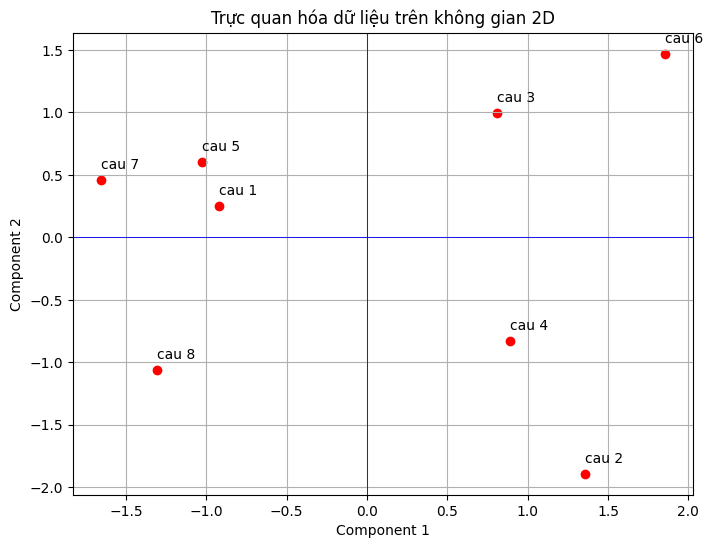

In [138]:
# Dữ liệu gồm 8 câu
labels = [f"cau {i+1}" for i in range(len(coords))]

plt.figure(figsize=(8,6))

# Vẽ biểu đồ phân tán
plt.scatter(coords[:,0], coords[:,1], color='red', marker="o")

for i in range(len(coords)):
    plt.annotate(
        labels[i],
        (coords[i,0], coords[i,1]),
        textcoords="offset points",
        xytext=(0,8),
        fontsize=10
    )

# Vẽ trục tọa độ
plt.axhline(0, color='blue', linewidth=0.6, linestyle='-')
plt.axvline(0, color='blue', linewidth=0.6, linestyle='-')

# Tiêu đề và nhãn
plt.title("Trực quan hóa dữ liệu trên không gian 2D")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid()

plt.show()

##  Nhận xét:

Sau khi giảm chiều bằng SVD xuống còn 2D: các câu có nội dung tương đồng nằm gần nhau trên biểu đồ.

SVD tìm các Components của dữ liệu:
+ Component 1: chứa lượng biến thiên lớn thứ nhất.
+ Component 2: chứa lượng biến thiên lớn thứ hai và vuông góc với Component 1.
Các trục này được xác định từ eigenvector và eigenvalue lớn nhất, do vậy, dữ liệu ban đầu sau khi được giảm chiều vẫn giữ được các thông tin quan trọng và có độ tương đồng với các câu khác.

## Bonus 10% 

Với text, tự cài bộ phân loại 1-NN dựa trên cosine.

In [139]:
def predict_1nn(query):
    v_query = to_vector(query)

    sim = consine_similarity(
        v_query.reshape(1,-1),
        X)[0]
    
    queen_idx = np.argmax(sim) # trả về vị trí của phần tử lớn nhất

    return labels[queen_idx], sim[queen_idx]
# nhãn của câu gần nhất
#điểm cosine tương ứng

print("Nhãn:", labels)
print("Cosine similarity:", score)

Nhãn: ['cau 1', 'cau 2', 'cau 3', 'cau 4', 'cau 5', 'cau 6', 'cau 7', 'cau 8']
Cosine similarity: [0.73029674 0.66666667 0.61237244]


## Giải thích bộ phân loại 1-NN

Ví dụ: query = "Toi yeu em den nay chung co the"
=> vector: [1,1,1,1,1,1,1,1]
=> cosine similarity: ["toi yeu em", "anh nho em", "den nay chung ta", "co the ben nhau"] = [0.61, 0.35, 0.51, 0.50] (lấy số ví dụ)
=> labels tương ứng: ["tinh yeu", "tinh yeu", "ky niem", "tuong lai"]
=> lớn nhất: 0.61
=> dự đoán nhãn: "tinh yeu"

1-NN hoạt động theo nguyên tắc: tìm kiếm câu có độ tương đồng cosine cao nhất trong tập dữ liệu. Câu được chọn sẽ được lấy nhãn làm kết quả dự đoán.